# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

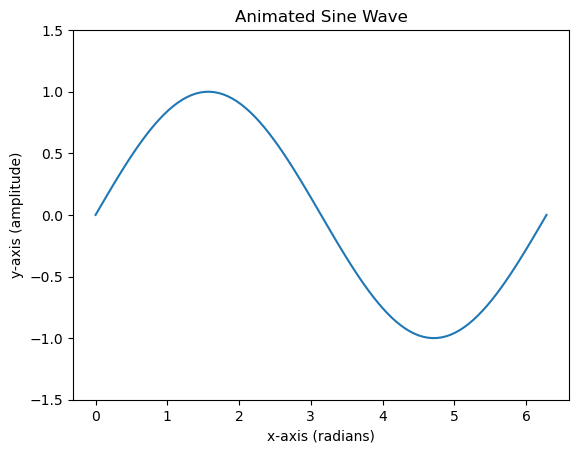

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

x = np.linspace(0, 2*np.pi, 100)
fig, ax = plt.subplots()
line, = ax.plot(x, np.sin(x))

ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("x-axis (radians)")
ax.set_ylabel("y-axis (amplitude)")
ax.set_title("Animated Sine Wave")

def update(frame):
    line.set_ydata(np.sin(x + frame / 5.0)) # Change from 10 to 5 to make the wave go twice as fast
    return line,

ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)
plt.show()

In [ ]:
# My kernel will not run any animation, not sure why

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [54]:
ani.save("animation.gif", writer="ffmpeg", fps=20)

MovieWriter ffmpeg unavailable; using Pillow instead.
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1513854332.py:22: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  dot.set_data(x, y)


Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [ ]:
# For true, only changes are redrawn and the graph/axes/title is reused. If false, everything is redone.

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

C:\Users\golde\AppData\Local\Temp\ipykernel_20368\2067278214.py:22: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  dot.set_data(x, y)
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\2067278214.py:22: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  dot.set_data(x, y)


<function matplotlib.pyplot.show(close=None, block=None)>

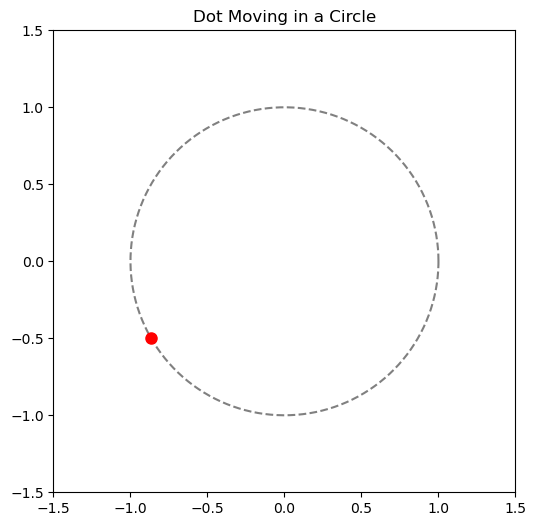

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_title("Dot Moving in a Circle")

# Circle reference (dashed)
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), '--', color='gray')

# Dot to animate
dot, = ax.plot([], [], 'ro', markersize=8)

def update(frame):
    angle = frame / 20 # speed
    x = np.cos(angle)
    y = np.sin(angle)
    dot.set_data(x, y)
    return dot,

ani = FuncAnimation(fig, update, frames=200, interval=20, blit=True)
ani.save("circle_dot.gif", writer="pillow", fps=30)

plt.show

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [64]:
# Gravitational constant (m^3 kg^-1 s^-2)
G = 6.67430e-11

# Masses (kg)
Ms = 1.989e30      # Sun
Me = 5.972e24      # Earth
Mm = 6.417e23      # Mars
Mc = 6.39e20       # The comet

# Distances (m)
AU = 1.496e11      # Astronomical unit (Earth-Sun distance)

# Time
daysec = 86400     # Seconds in a day
yearsec = 365.25 * daysec  # Seconds in a year

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [67]:
e_ap_v = 29291  # m/s
m_ap_v = 21970
commet_v = 7000

Run the cell below to define some gravitational constants because we expect no mass loss:

In [69]:
# There's no code to run here

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [71]:
# Earth at aphelion
xe, ye, ze = 1.0167 * AU, 0, 0

# Mars at aphelion
xm, ym, zm = 1.666 * AU, 0, 0

# Comet's initial position
xc, yc, zc = 2 * AU, 0.3 * AU, 0

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [73]:
# Earth
xve, yve, zve = 0, e_ap_v, 0

# Mars
xvm, yvm, zvm = 0, m_ap_v, 0

# Comet
xvc, yvc, zvc = 0, commet_v, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [75]:
# Sun's initial position (at origin)
xs, ys, zs = 0, 0, 0

# Sun's initial velocity (motionless)
xvs, yvs, zvs = 0, 0, 0

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [87]:
t = 0                      # Initial time (seconds)
dt = 1 * daysec            # Time step: 1 day in seconds
years = 5                  # Number of years to simulate
sim_years = years * 365 * daysec  # Total simulation time in seconds

Create empty lists to store all of your varibles. Run the cell below.

In [95]:
# Sun
xs_list, ys_list, zs_list = [], [], []
xvs_list, yvs_list, zvs_list = [], [], []

# Earth
xe_list, ye_list, ze_list = [], [], []
xve_list, yve_list, zve_list = [], [], []

# Mars
xm_list, ym_list, zm_list = [], [], []
xvm_list, yvm_list, zvm_list = [], [], []

# Comet
xc_list, yc_list, zc_list = [], [], []
xvc_list, yvc_list, zvc_list = [], [], []

## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [93]:
gravconst_e = G * Ms * Me
gravconst_m = G * Ms * Mm
gravconst_c = G * Ms * Mc

################ Earth #############
rx, ry, rz = xe - xs, ye - ys, ze - zs
modr3_e = (rx**2 + ry**2 + rz**2)**1.5
fx_e = -gravconst_e * rx / modr3_e
fy_e = -gravconst_e * ry / modr3_e
    
xve += fx_e * dt / Me
yve += fy_e * dt / Me
xe += xve * dt
ye += yve * dt
    
xe_list.append(xe)
ye_list.append(ye)

################ Mars ##############
rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
fx_m = -gravconst_m * rx_m / modr3_m
fy_m = -gravconst_m * ry_m / modr3_m
    
xvm += fx_m * dt / Mm
yvm += fy_m * dt / Mm
xm += xvm * dt
ym += yvm * dt
    
xm_list.append(xm)
ym_list.append(ym)

################ Comet ##############
rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
fx_c = -gravconst_c * rx_c / modr3_c
fy_c = -gravconst_c * ry_c / modr3_c
    
xvc += fx_c * dt / Mc
yvc += fy_c * dt / Mc
xc += xvc * dt
yc += yvc * dt
    
xc_list.append(xc)
yc_list.append(yc)

################ Sun ##############
xvs += -(fx_e + fx_m) * dt / Ms
yvs += -(fy_e + fy_m) * dt / Ms
xs += xvs * dt
ys += yvs * dt

xs_list.append(xs)
ys_list.append(ys)

t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

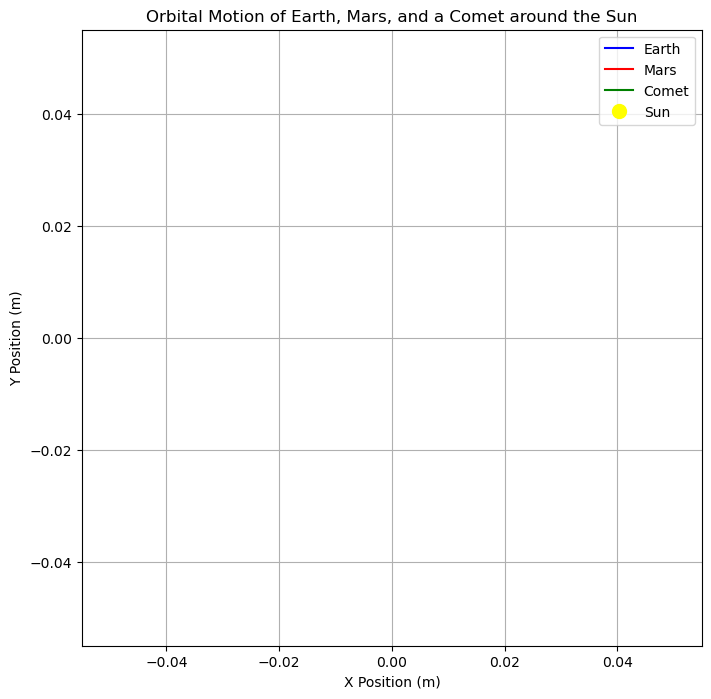

In [99]:
plt.figure(figsize=(8, 8))

# Orbits
plt.plot(xe_list, ye_list, label="Earth", color="blue")
plt.plot(xm_list, ym_list, label="Mars", color="red")
plt.plot(xc_list, yc_list, label="Comet", color="green")

# Sun
plt.plot(xs_list, ys_list, 'o', color="yellow", label="Sun", markersize=10)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Orbital Motion of Earth, Mars, and a Comet around the Sun")
plt.legend()
plt.grid(True)

plt.show()

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

C:\Users\golde\AppData\Local\Temp\ipykernel_20368\995978693.py:35: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xe_list[i], ye_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\995978693.py:36: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_m.set_data(xm_list[i], ym_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\995978693.py:37: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_c.set_data(xc_list[i], yc_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\995978693.py:38: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_s.set_data(xs_list[i], ys_list[i])


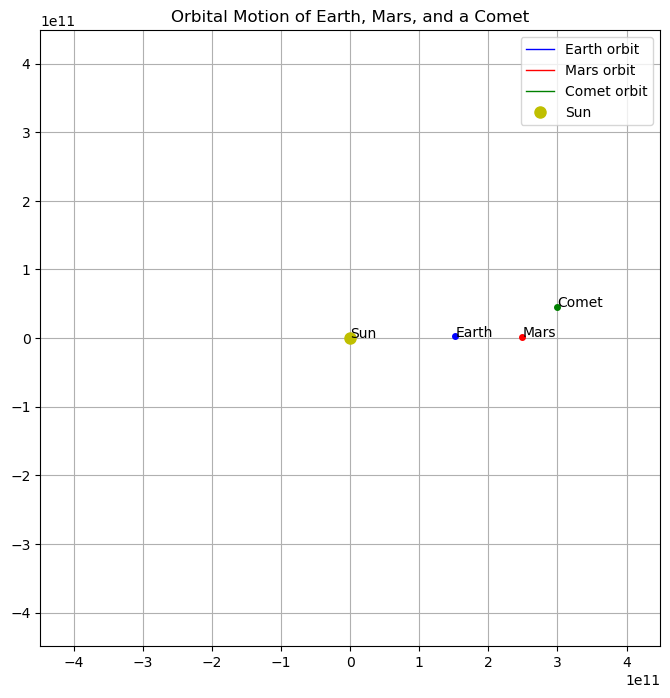

In [120]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)
ax.set_title("Orbital Motion of Earth, Mars, and a Comet")

# Plot the orbit trails (lines)
line_e, = ax.plot([], [], '-b', lw=1, label='Earth orbit')
line_m, = ax.plot([], [], '-r', lw=1, label='Mars orbit')
line_c, = ax.plot([], [], '-g', lw=1, label='Comet orbit')

# Plot the moving bodies (points)
point_e, = ax.plot([], [], 'bo', markersize=4)
point_m, = ax.plot([], [], 'ro', markersize=4)
point_c, = ax.plot([], [], 'go', markersize=4)
point_s, = ax.plot([], [], 'yo', markersize=8, label='Sun')

text_e = ax.text(AU, 0, 'Earth')
text_m = ax.text(1.5 * AU, 0, 'Mars')
text_c = ax.text(2 * AU, 0.3 * AU, 'Comet')
text_s = ax.text(0.1 * AU, 0.1 * AU, 'Sun')

ax.legend()
ax.grid(True)

def update(i):
    
    line_e.set_data(xe_list[:i], ye_list[:i])
    line_m.set_data(xm_list[:i], ym_list[:i])
    line_c.set_data(xc_list[:i], yc_list[:i])
    
    point_e.set_data(xe_list[i], ye_list[i])
    point_m.set_data(xm_list[i], ym_list[i])
    point_c.set_data(xc_list[i], yc_list[i])
    point_s.set_data(xs_list[i], ys_list[i])

    text_e.set_position((xe_list[i], ye_list[i]))
    text_m.set_position((xm_list[i], ym_list[i]))
    text_c.set_position((xc_list[i], yc_list[i]))
    text_s.set_position((xs_list[i], ys_list[i]))

    return (line_e, line_m, line_c, point_e, point_m, point_c, point_s,
            text_e, text_m, text_c, text_s)

ani = FuncAnimation(fig, update, frames=len(xe_list), interval=1, blit=True)

plt.show()


## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

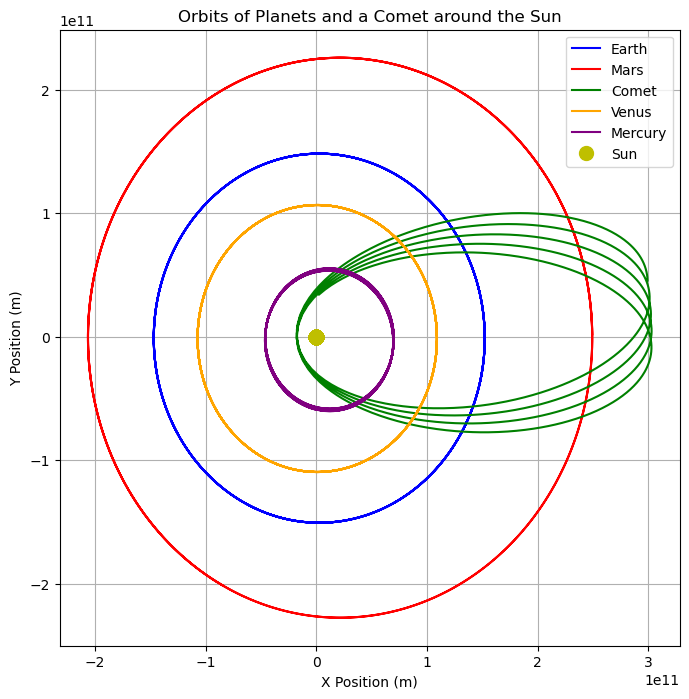

C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:169: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xe_list[i], ye_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:170: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_m.set_data(xm_list[i], ym_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:171: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_c.set_data(xc_list[i], yc_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:172: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_v.set_data(xv_list[i], yv_list[i])
C:\Users

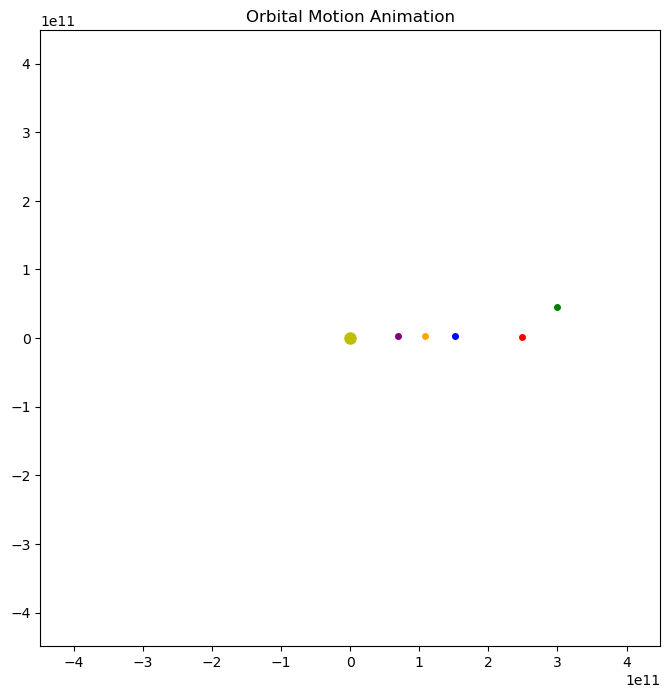

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Constants
G = 6.67430e-11
AU = 1.496e11
daysec = 86400
years = 5
sim_years = years * 365 * daysec
dt = 1 * daysec
t = 0

# Masses
Ms = 1.989e30       # Sun
Me = 5.972e24       # Earth
Mm = 6.417e23       # Mars
Mc = 6.39e20        # Comet
Mv = 4.867e24       # Venus
Mmer = 3.301e23     # Mercury

# Initial Positions
xe, ye = 1.0167 * AU, 0
xm, ym = 1.666 * AU, 0
xc, yc = 2 * AU, 0.3 * AU
xv, yv = 0.728 * AU, 0
xmer, ymer = 0.467 * AU, 0
xs, ys = 0, 0

# Initial Velocities
e_ap_v = 29291
m_ap_v = 21970
commet_v = 7000
v_ap_v = 34790
mer_ap_v = 38860

xve, yve = 0, e_ap_v
xvm, yvm = 0, m_ap_v
xvc, yvc = 0, commet_v
xvv, yvv = 0, v_ap_v
xvmer, yvmer = 0, mer_ap_v
xvs, yvs = 0, 0

def grav_const(m1, m2):
    return G * m1 * m2

# Lists
xe_list, ye_list = [], []
xm_list, ym_list = [], []
xc_list, yc_list = [], []
xv_list, yv_list = [], []
xmer_list, ymer_list = [], []
xs_list, ys_list = [], []

# Loop
while t < sim_years:
    # Earth
    rx, ry = xe - xs, ye - ys
    modr3 = (rx**2 + ry**2)**1.5
    fxe = -grav_const(Ms, Me) * rx / modr3
    fye = -grav_const(Ms, Me) * ry / modr3
    xve += fxe * dt / Me
    yve += fye * dt / Me
    xe += xve * dt
    ye += yve * dt
    xe_list.append(xe)
    ye_list.append(ye)

    # Mars
    rx, ry = xm - xs, ym - ys
    modr3 = (rx**2 + ry**2)**1.5
    fxm = -grav_const(Ms, Mm) * rx / modr3
    fym = -grav_const(Ms, Mm) * ry / modr3
    xvm += fxm * dt / Mm
    yvm += fym * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
    xm_list.append(xm)
    ym_list.append(ym)

    # Comet
    rx, ry = xc - xs, yc - ys
    modr3 = (rx**2 + ry**2)**1.5
    fxc = -grav_const(Ms, Mc) * rx / modr3
    fyc = -grav_const(Ms, Mc) * ry / modr3
    xvc += fxc * dt / Mc
    yvc += fyc * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
    xc_list.append(xc)
    yc_list.append(yc)

    # Venus
    rx, ry = xv - xs, yv - ys
    modr3 = (rx**2 + ry**2)**1.5
    fxv = -grav_const(Ms, Mv) * rx / modr3
    fyv = -grav_const(Ms, Mv) * ry / modr3
    xvv += fxv * dt / Mv
    yvv += fyv * dt / Mv
    xv += xvv * dt
    yv += yvv * dt
    xv_list.append(xv)
    yv_list.append(yv)

    # Mercury
    rx, ry = xmer - xs, ymer - ys
    modr3 = (rx**2 + ry**2)**1.5
    fxmer = -grav_const(Ms, Mmer) * rx / modr3
    fymer = -grav_const(Ms, Mmer) * ry / modr3
    xvmer += fxmer * dt / Mmer
    yvmer += fymer * dt / Mmer
    xmer += xvmer * dt
    ymer += yvmer * dt
    xmer_list.append(xmer)
    ymer_list.append(ymer)

    # Sun motion
    xvs += -(fxe + fxm + fxv) * dt / Ms
    yvs += -(fye + fym + fyv) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xs_list.append(xs)
    ys_list.append(ys)

    t += dt

# --- Plotting Orbits ---
plt.figure(figsize=(8, 8))
plt.plot(xe_list, ye_list, label="Earth", color="blue")
plt.plot(xm_list, ym_list, label="Mars", color="red")
plt.plot(xc_list, yc_list, label="Comet", color="green")
plt.plot(xv_list, yv_list, label="Venus", color="orange")
plt.plot(xmer_list, ymer_list, label="Mercury", color="purple")
plt.plot(xs_list, ys_list, 'yo', label="Sun", markersize=10)
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Orbits of Planets and a Comet around the Sun")
plt.legend()
plt.grid(True)
plt.show()

# --- Animation ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)
ax.set_title("Orbital Motion Animation")

line_e, = ax.plot([], [], '-', color='blue', lw=1)
line_m, = ax.plot([], [], '-', color='red', lw=1)
line_c, = ax.plot([], [], '-', color='green', lw=1)
line_v, = ax.plot([], [], '-', color='orange', lw=1)
line_mer, = ax.plot([], [], '-', color='purple', lw=1)

point_e, = ax.plot([], [], 'bo', markersize=4)
point_m, = ax.plot([], [], 'ro', markersize=4)
point_c, = ax.plot([], [], 'go', markersize=4)
point_v, = ax.plot([], [], 'o', color='orange', markersize=4)
point_mer, = ax.plot([], [], 'o', color='purple', markersize=4)
point_s, = ax.plot([], [], 'yo', markersize=8)

def update(i):
    line_e.set_data(xe_list[:i], ye_list[:i])
    line_m.set_data(xm_list[:i], ym_list[:i])
    line_c.set_data(xc_list[:i], yc_list[:i])
    line_v.set_data(xv_list[:i], yv_list[:i])
    line_mer.set_data(xmer_list[:i], ymer_list[:i])

    point_e.set_data(xe_list[i], ye_list[i])
    point_m.set_data(xm_list[i], ym_list[i])
    point_c.set_data(xc_list[i], yc_list[i])
    point_v.set_data(xv_list[i], yv_list[i])
    point_mer.set_data(xmer_list[i], ymer_list[i])
    point_s.set_data(xs_list[i], ys_list[i])

    return (line_e, line_m, line_c, line_v, line_mer,
            point_e, point_m, point_c, point_v, point_mer, point_s)

ani = FuncAnimation(fig, update, frames=len(xe_list), interval=1, blit=True)
plt.show()


Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [117]:
ani = FuncAnimation(fig, update, frames=len(xe_list), interval=1, blit=True)
ani.save("solar_system.gif", writer='pillow', fps=30)

C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:169: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xe_list[i], ye_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:170: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_m.set_data(xm_list[i], ym_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:171: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_c.set_data(xc_list[i], yc_list[i])
C:\Users\golde\AppData\Local\Temp\ipykernel_20368\1573630462.py:172: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_v.set_data(xv_list[i], yv_list[i])
C:\Users

Upload this notebook and your animations to Gradescope!